In [155]:
import pandas as pd
import matplotlib.pyplot as plt

In [156]:
simulation_df = pd.read_csv("../results/simulation_results.csv")
trajectory_df = pd.read_csv("../results/trajectory_results.csv")

In [157]:
simulation_df.head()

,run_id,N,T,initial_corruption_rate_parameter,beta,gamma,alpha,memory_endowment,collaboration_cost,discount_factor,initial_num_corrupted,initial_corruption_rate_actual,final_num_corrupted,final_num_honest,final_corruption_rate,spread_amount,spread_rate_change,full_corruption,no_spread,belief_cutoff
0,0,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,18,0.0450,26,374,0.0650,8,0.0200,False,False,0.034102
1,1,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,19,0.0475,21,379,0.0525,2,0.0050,False,False,0.034102
2,2,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,16,0.0400,19,381,0.0475,3,0.0075,False,False,0.034102
3,3,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,16,0.0400,18,382,0.0450,2,0.0050,False,False,0.034102
4,4,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,14,0.0350,19,381,0.0475,5,0.0125,False,False,0.034102


In [158]:
trajectory_df.head()

,run_id,time_step,period,N,T,initial_corruption_rate_parameter,beta,gamma,alpha,memory_endowment,collaboration_cost,discount_factor,num_corrupted,num_honest,corruption_rate,collaboration_rate,belief_cutoff
0,0,0,1,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,18,382,0.0450,0.000,0.026436
1,0,1,2,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,19,381,0.0475,0.370,0.026436
2,0,2,3,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,20,380,0.0500,0.395,0.026436
3,0,3,4,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,21,379,0.0525,0.505,0.026436
4,0,4,5,400,100,0.05,0.5,0.4,0.9,1.0,0.02,0.9,22,378,0.0550,0.510,0.026436


Final corruption rate distribution

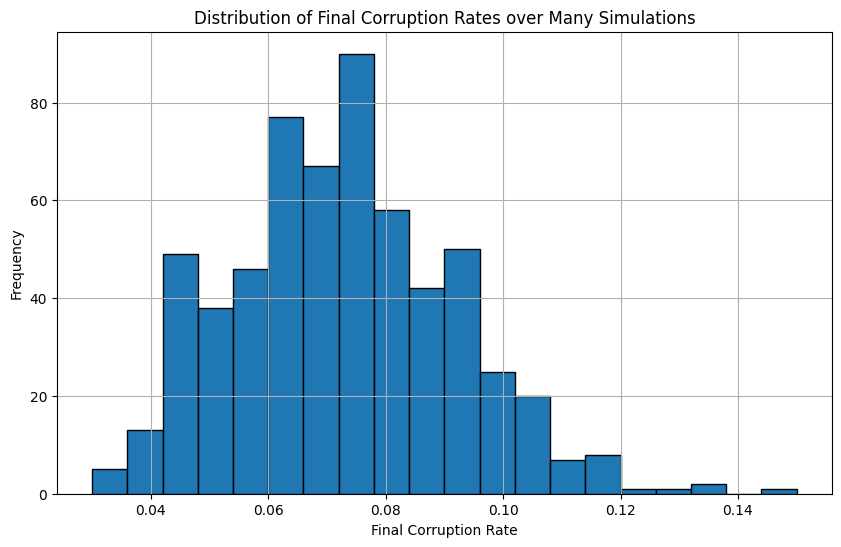

In [159]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_df["final_corruption_rate"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Final Corruption Rate")
plt.ylabel("Frequency")
plt.title("Distribution of Final Corruption Rates over Many Simulations")
plt.grid(True)

plt.savefig("../figures/final_corruption_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Spread amount distribution

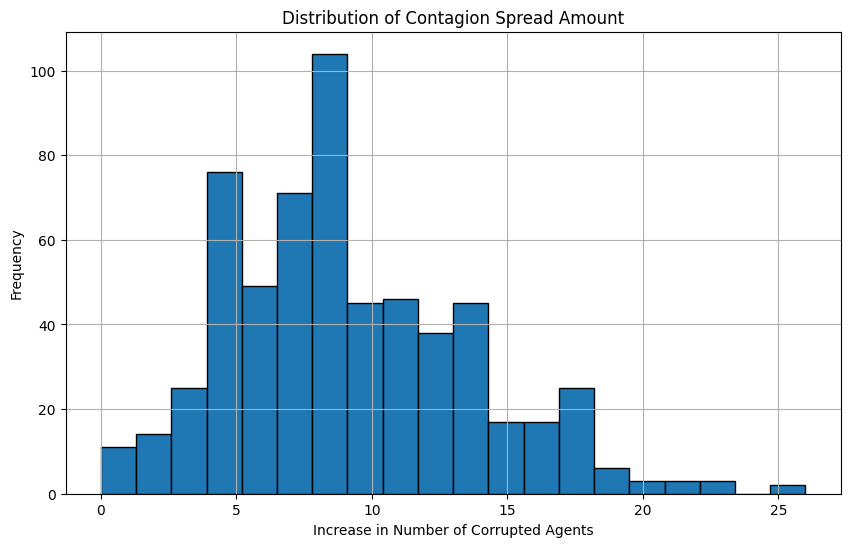

In [161]:
plt.figure(figsize=(10, 6))

plt.hist(
    simulation_df["spread_amount"],
    bins=20,
    edgecolor="black"
)

plt.xlabel("Increase in Number of Corrupted Agents")
plt.ylabel("Frequency")
plt.title("Distribution of Contagion Spread Amount")
plt.grid(True)

plt.savefig("../figures/spread_amount_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Corruption trajectories

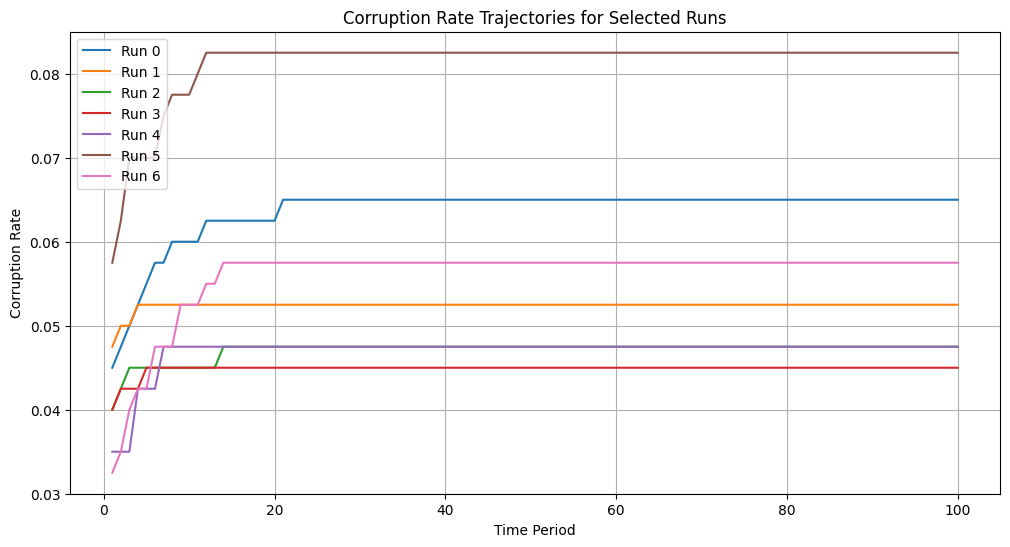

In [162]:
plt.figure(figsize=(12, 6))

for run_id in trajectory_df["run_id"].unique():
    run_data = trajectory_df[trajectory_df["run_id"] == run_id]

    plt.plot(
        run_data["period"],
        run_data["corruption_rate"],
        label=f"Run {run_id}"
    )

plt.xlabel("Time Period")
plt.ylabel("Corruption Rate")
plt.title("Corruption Rate Trajectories for Selected Runs")
plt.legend()
plt.grid(True)

plt.savefig("../figures/selected_corruption_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

Collaboration trajectories

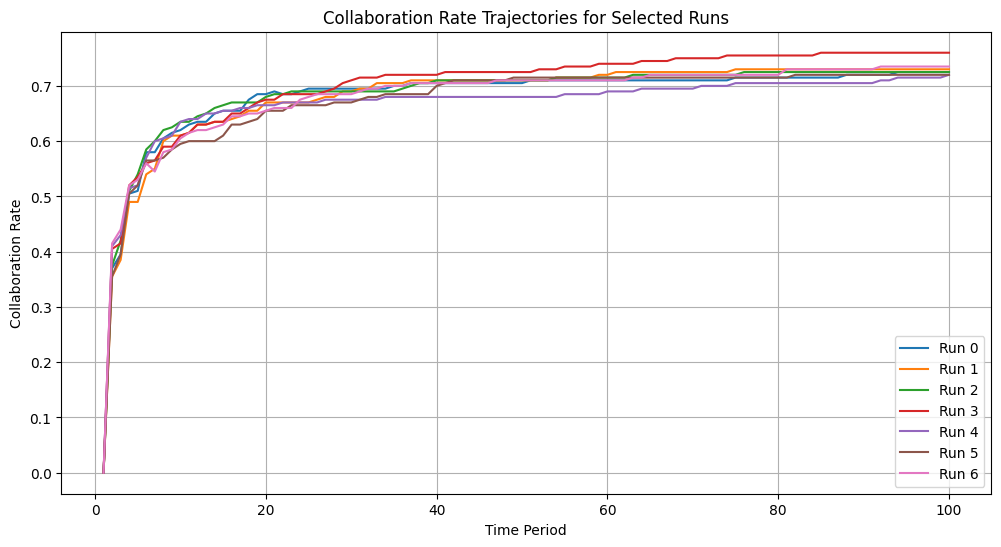

In [163]:
plt.figure(figsize=(12, 6))

for run_id in trajectory_df["run_id"].unique():
    run_data = trajectory_df[trajectory_df["run_id"] == run_id]

    plt.plot(
        run_data["period"],
        run_data["collaboration_rate"],
        label=f"Run {run_id}"
    )

plt.xlabel("Time Period")
plt.ylabel("Collaboration Rate")
plt.title("Collaboration Rate Trajectories for Selected Runs")
plt.legend()
plt.grid(True)

plt.savefig("../figures/selected_collaboration_trajectories.png", dpi=300, bbox_inches="tight")
plt.show()

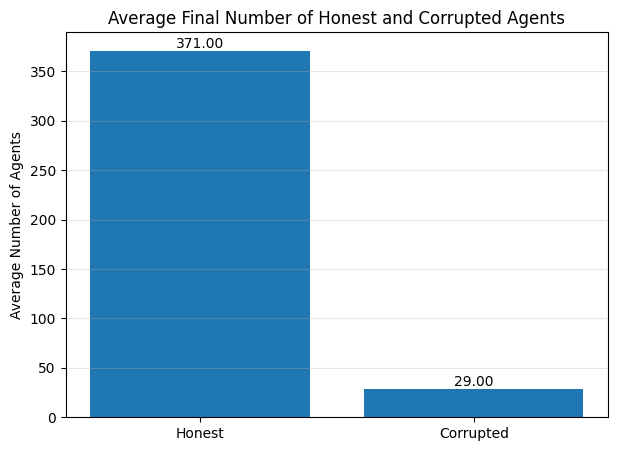

In [164]:
mean_final_honest = simulation_df["final_num_honest"].mean()
mean_final_corrupted = simulation_df["final_num_corrupted"].mean()

plt.figure(figsize=(7, 5))

bars = plt.bar(
    ["Honest", "Corrupted"],
    [mean_final_honest, mean_final_corrupted]
)

plt.ylabel("Average Number of Agents")
plt.title("Average Final Number of Honest and Corrupted Agents")
plt.grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.savefig("../figures/average_final_honest_corrupted.png", dpi=300, bbox_inches="tight")
plt.show()